# Exploratory Data Analysis (EDA)
## Restaurant Demand Forecasting

This notebook performs a detailed analysis of the restaurant demand dataset.
Objectives:
- Understand data structure and quality
- Identify patterns and trends
- Analyze relationships between features and targets

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Load Dataset

In [4]:
df = pd.read_csv('../dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Day_of_Week,Is_Weekend,Season,Weather_Type,Special_Occasion,Holiday,Total_Customers,LPG_Usage_kg,Dosa_Sold,Idly_Sold,Vada_Sold,Puri_Sold
0,2020-01-01,Wednesday,0,Winter,Cold,Local Event,0,262,5.61,61,67,60,74
1,2020-01-02,Thursday,0,Winter,Cold,No Occasion,0,316,7.05,94,77,74,71
2,2020-01-03,Friday,0,Winter,Cold,No Occasion,0,281,6.71,60,107,18,96
3,2020-01-04,Saturday,1,Winter,Cold,Festival,1,760,17.67,184,137,165,274
4,2020-01-05,Sunday,1,Winter,Sunny,No Occasion,0,495,14.39,135,104,91,165


## 2. Basic Information

In [5]:
print("Shape of the dataset:", df.shape)
print("\nInfo:")
df.info()

Shape of the dataset: (7500, 13)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              7500 non-null   datetime64[ns]
 1   Day_of_Week       7500 non-null   object        
 2   Is_Weekend        7500 non-null   int64         
 3   Season            7500 non-null   object        
 4   Weather_Type      7500 non-null   object        
 5   Special_Occasion  7500 non-null   object        
 6   Holiday           7500 non-null   int64         
 7   Total_Customers   7500 non-null   int64         
 8   LPG_Usage_kg      7500 non-null   float64       
 9   Dosa_Sold         7500 non-null   int64         
 10  Idly_Sold         7500 non-null   int64         
 11  Vada_Sold         7500 non-null   int64         
 12  Puri_Sold         7500 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int6

In [6]:
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
df.describe()


Missing Values:
Date                0
Day_of_Week         0
Is_Weekend          0
Season              0
Weather_Type        0
Special_Occasion    0
Holiday             0
Total_Customers     0
LPG_Usage_kg        0
Dosa_Sold           0
Idly_Sold           0
Vada_Sold           0
Puri_Sold           0
dtype: int64

Statistical Summary:


,Date,Is_Weekend,Holiday,Total_Customers,LPG_Usage_kg,Dosa_Sold,Idly_Sold,Vada_Sold,Puri_Sold
count,7500,7500.00000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,2030-04-07 12:00:00,0.28560,0.175600,346.812533,8.673348,105.040133,94.713467,73.311467,73.747467
min,2020-01-01 00:00:00,0.00000,0.000000,80.000000,1.670000,9.000000,6.000000,1.000000,0.000000
25%,2025-02-17 18:00:00,0.00000,0.000000,274.000000,6.690000,77.000000,71.000000,47.000000,36.000000
50%,2030-04-07 12:00:00,0.00000,0.000000,329.000000,8.200000,101.000000,92.000000,67.500000,61.000000
75%,2035-05-26 06:00:00,1.00000,0.000000,397.000000,10.110000,128.000000,116.000000,93.000000,94.000000
max,2040-07-13 00:00:00,1.00000,1.000000,840.000000,23.320000,276.000000,242.000000,264.000000,353.000000
std,NaN,0.45173,0.380505,112.415446,2.983325,38.093485,32.759280,37.149888,54.868493


## 3. Univariate Analysis (Distributions)

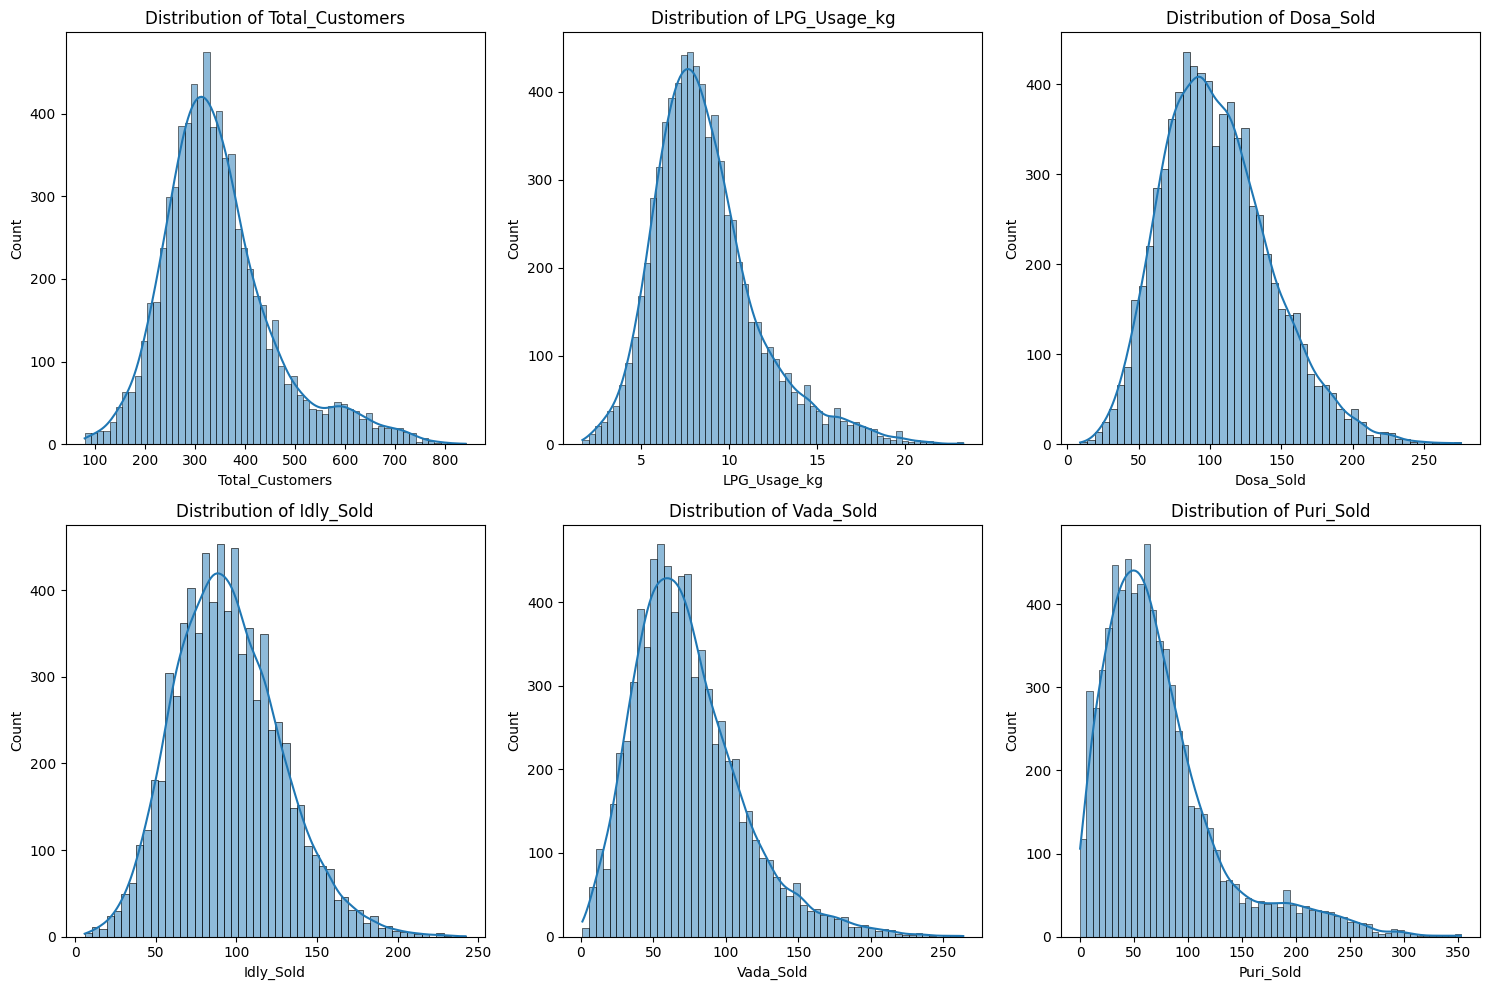

In [7]:
targets = ['Total_Customers', 'LPG_Usage_kg', 'Dosa_Sold', 'Idly_Sold', 'Vada_Sold', 'Puri_Sold']

plt.figure(figsize=(15, 10))
for i, col in enumerate(targets):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## 4. Bivariate Analysis

### Correlation Heatmap

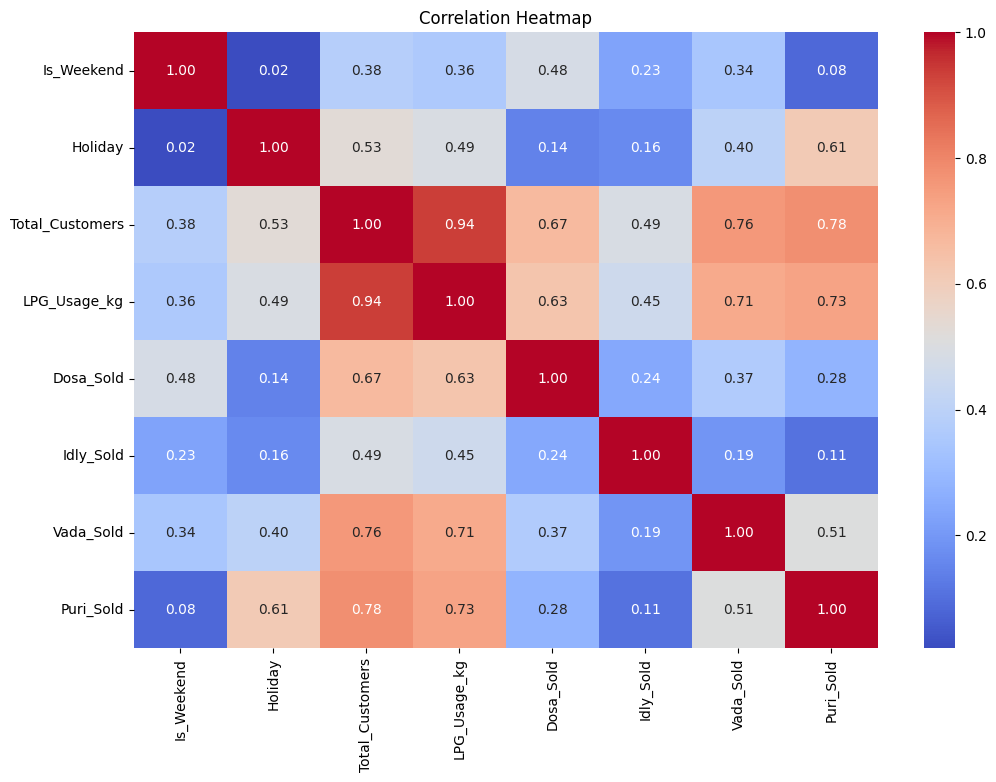

In [8]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Weekend vs Sales

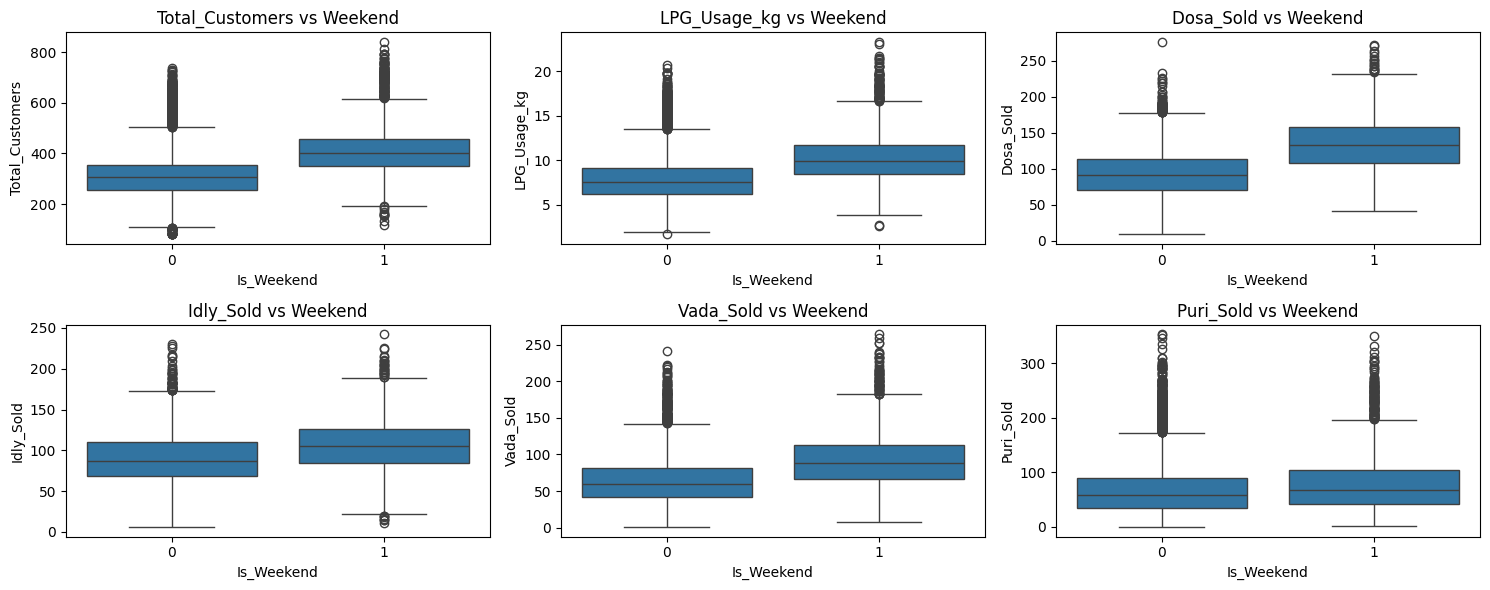

In [9]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(targets):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Is_Weekend', y=col, data=df)
    plt.title(f'{col} vs Weekend')
plt.tight_layout()
plt.show()

### Weather Impact

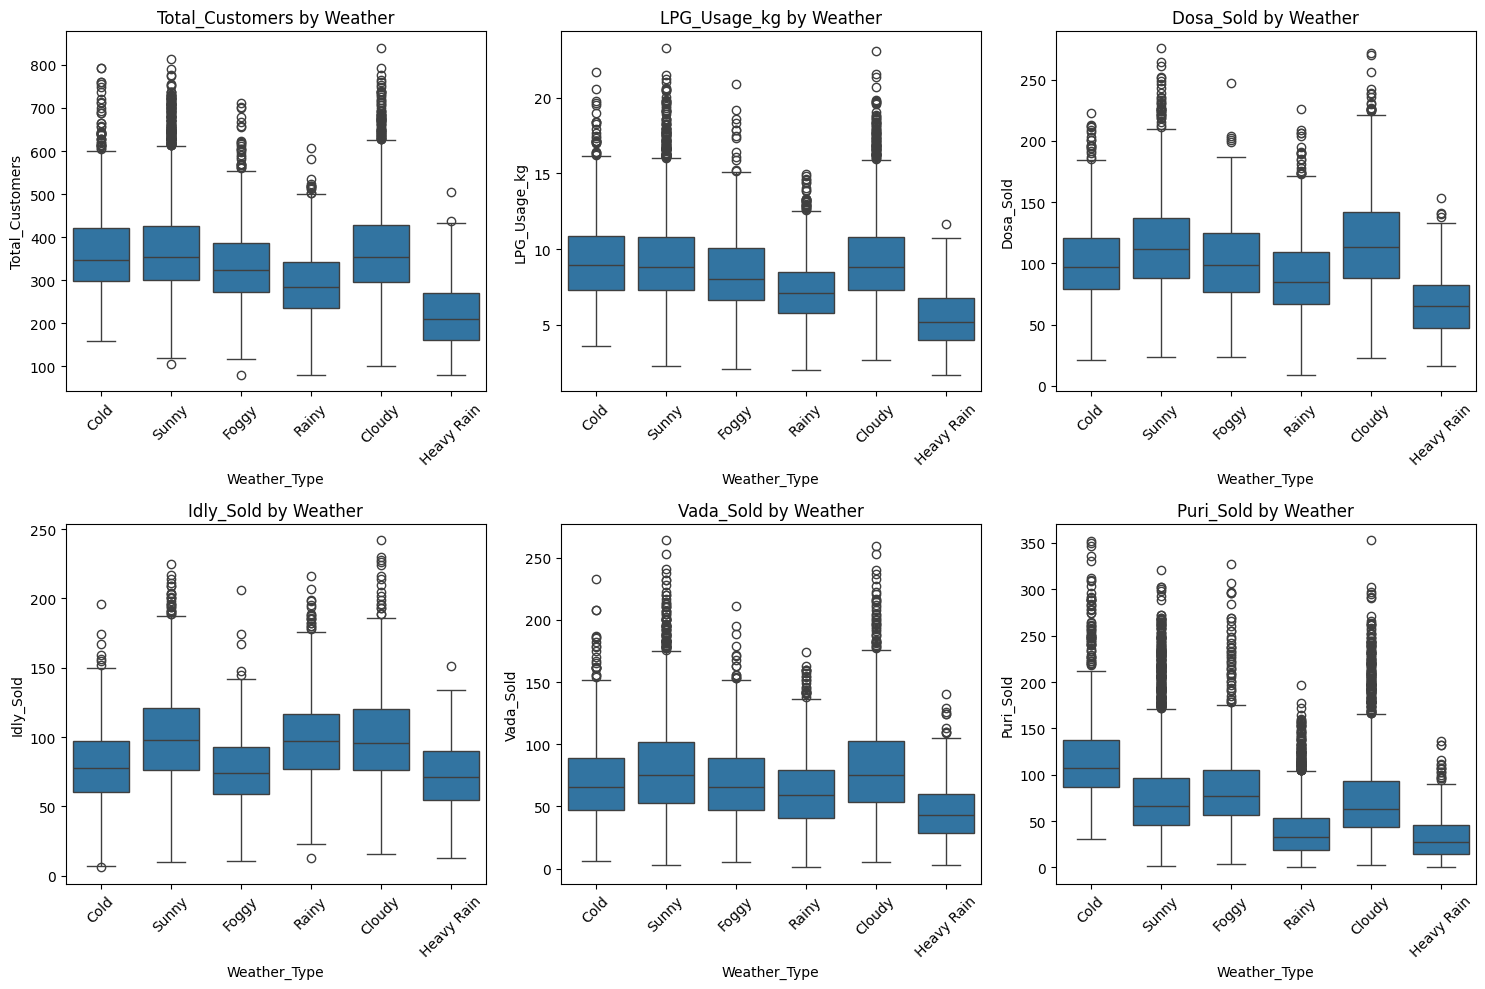

In [10]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(targets):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Weather_Type', y=col, data=df)
    plt.title(f'{col} by Weather')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Holiday Impact

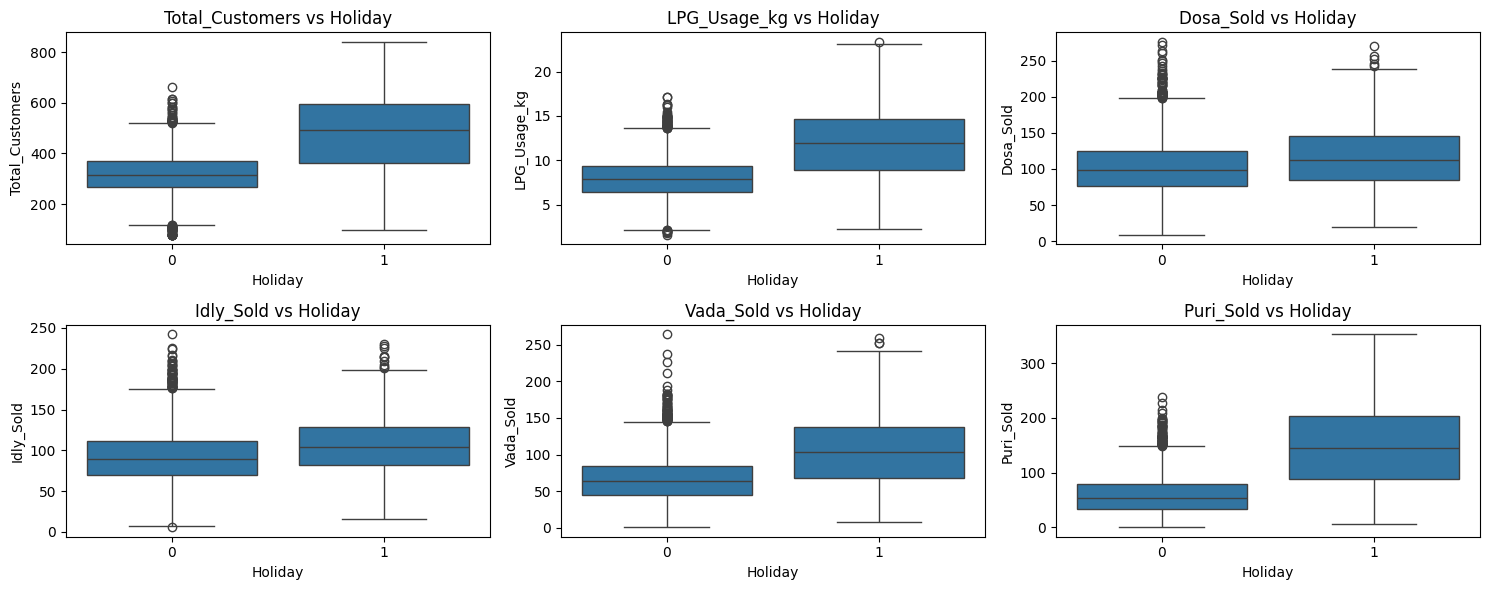

In [11]:
plt.figure(figsize=(15, 6))
for i, col in enumerate(targets):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='Holiday', y=col, data=df)
    plt.title(f'{col} vs Holiday')
plt.tight_layout()
plt.show()

## 5. Seasonality Patterns

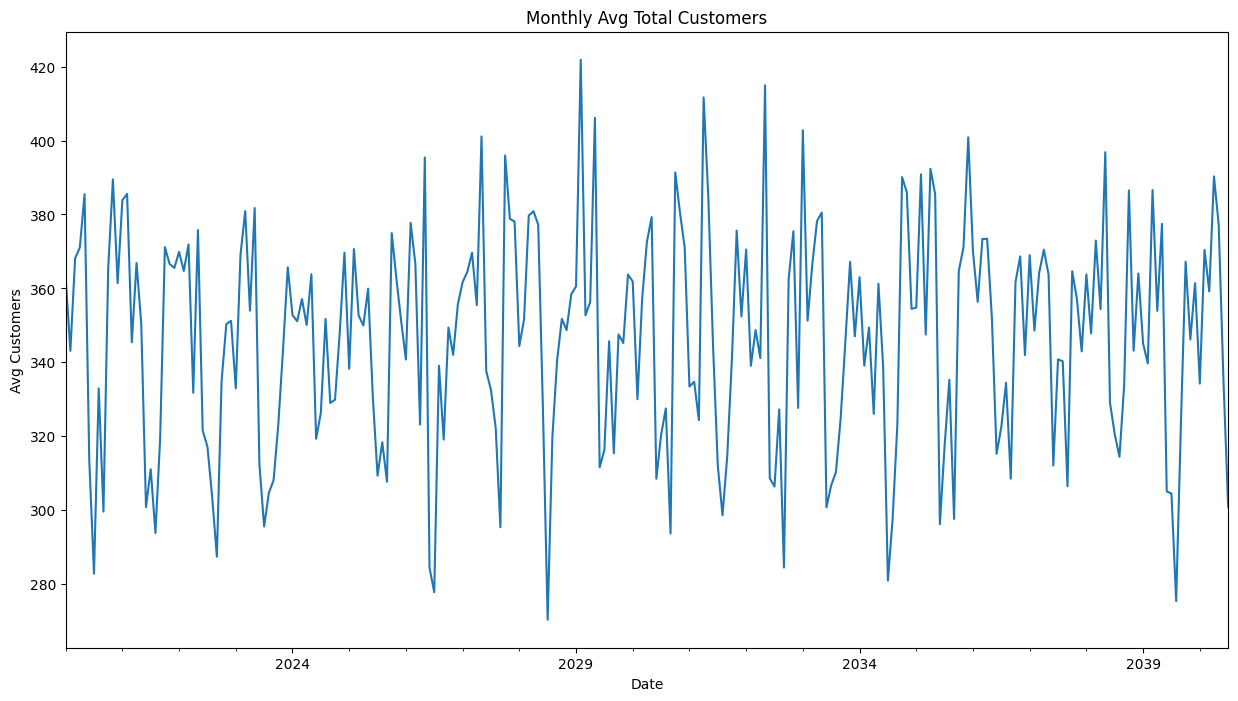

In [12]:
df.set_index('Date', inplace=True)
plt.figure(figsize=(15, 8))
df['Total_Customers'].resample('M').mean().plot()
plt.title('Monthly Avg Total Customers')
plt.ylabel('Avg Customers')
plt.show()
df.reset_index(inplace=True)

## 6. Automated Profile Report

In [13]:
# profile = ProfileReport(df, title="Restaurant Demand Profiling Report")
# profile.to_file("restaurant_demand_report.html")
# print("Profile report saved to restaurant_demand_report.html")